# Sustainability Aware Asset Management — Final Notebook

**Group AU** — Region: **Europe (EUR)** — Scope: **Scope 1 + Scope 2**

This notebook reproduces all results reported in the project: data cleaning,
Part I (standard portfolio allocation), Part II (carbon-aware allocations).
Run all cells top-to-bottom. The only requirement is that the raw Datastream
files supplied with the project are available in `./data_raw/`.

## Use of Large Language Models (LLMs)

We used GPT-class assistants (Claude, ChatGPT) for: (i) debugging numerical
issues with the SLSQP optimizer (e.g., dealing with singular covariance
matrices through ridge regularization and scaling), (ii) checking whether the
implementation of each step matched the wording of the project PDF, and (iii)
polishing the language of the report. All methodological choices, code
decisions, results, and the interpretation of findings are our own work, and
the group remains fully responsible for correctness and academic integrity.


## 0. Setup

We import the standard scientific stack and `scipy.optimize.minimize`, set
deterministic paths relative to the notebook, and create the output folders if
they don't exist.


In [1]:
%matplotlib inline

import warnings
from pathlib import Path
from typing import Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Silence harmless SLSQP probing warnings on near-singular Sigma; covariance
# is already regularized below.
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*matmul.*")
warnings.filterwarnings("ignore", category=UserWarning, message=".*non-interactive.*")
warnings.filterwarnings("ignore", category=FutureWarning)
np.seterr(divide="ignore", over="ignore", invalid="ignore")

DATA_DIR = Path("data_raw")
OUTPUT_PART1 = Path("outputs_part1")
OUTPUT_PART2 = Path("outputs_part2")
OUTPUT_PART1.mkdir(parents=True, exist_ok=True)
OUTPUT_PART2.mkdir(parents=True, exist_ok=True)

REGION = "EUR"
START_REBAL_YEAR = 2013
END_REBAL_YEAR = 2024
ESTIMATION_MONTHS = 120
MIN_MONTHLY_OBS = 36
STALE_ZERO_RETURN_THRESHOLD = 0.5
PRICE_FLOOR = 0.5
CF_REDUCTION = 0.5
NZ_THETA = 0.10


## 1. Load raw data and apply the EUR region filter

We load the eight Datastream files. For each panel (returns, market cap,
emissions, etc.) we keep only firms in the assigned region (EUR) and drop
firms with no time-series data at all. We then take the intersection of ISINs
across all panels, so that every firm has *some* data in every variable.


In [2]:
def _load_panel(filename: str, candidate_filenames: Optional[List[str]] = None) -> pd.DataFrame:
    candidates = [filename] + (candidate_filenames or [])
    for name in candidates:
        path = DATA_DIR / name
        if path.exists():
            df = pd.read_excel(path)
            df.columns = [c if not isinstance(c, str) else c.strip() for c in df.columns]
            return df
    raise FileNotFoundError(f"None of {candidates} found in {DATA_DIR}")


static = _load_panel("Static_2025.xlsx", ["Static.xlsx"])
co2_s1 = _load_panel("DS_CO2_SCOPE_1_Y_2025.xlsx", ["DS CO2 SCOPE 1.xlsx"])
co2_s2 = _load_panel("DS_CO2_SCOPE_2_Y_2025.xlsx", ["DS CO2 SCOPE 2.xlsx"])
rev_y_raw = _load_panel("DS_REV_Y_2025.xlsx", ["DS REV USD Y.xlsx"])
mv_y_raw = _load_panel("DS_MV_T_USD_Y_2025.xlsx", ["DS MV T USD Y.xlsx"])
mv_m_raw = _load_panel("DS_MV_T_USD_M_2025.xlsx", ["DS MV T USD M.xlsx"])
ri_y_raw = _load_panel("DS_RI_T_USD_Y_2025.xlsx", ["DS RI T USD Y.xlsx"])
ri_m_raw = _load_panel("DS_RI_T_USD_M_2025.xlsx", ["DS RI T USD M.xlsx"])

print("Static:", static.shape, "| Region values:", static["Region"].unique())


Static: (2545, 4) | Region values: ['AMER' 'EM' 'EUR' 'PAC' 'Other' 'FRON']


In [3]:
def _set_isin_index(df: pd.DataFrame) -> pd.DataFrame:
    if "ISIN" not in df.columns:
        raise ValueError(f"No ISIN column in {df.columns.tolist()[:5]}")
    out = df.copy()
    out["ISIN"] = out["ISIN"].astype(str).str.strip()
    out = out.dropna(subset=["ISIN"]).drop_duplicates(subset=["ISIN"]).set_index("ISIN")
    return out


static = _set_isin_index(static)
eur_isins = static.index[static["Region"].astype(str).str.upper() == REGION]
print(f"Number of firms in static (any region): {len(static)}")
print(f"Number of EUR firms in static:           {len(eur_isins)}")


def _prep_panel(df: pd.DataFrame, eur_isins: Iterable[str]) -> pd.DataFrame:
    out = _set_isin_index(df).drop(columns=["NAME"], errors="ignore")
    out = out.loc[out.index.intersection(eur_isins)]
    out = out.apply(pd.to_numeric, errors="coerce")
    return out


co2_s1 = _prep_panel(co2_s1, eur_isins)
co2_s2 = _prep_panel(co2_s2, eur_isins)
rev_y = _prep_panel(rev_y_raw, eur_isins)
mv_y = _prep_panel(mv_y_raw, eur_isins)
mv_m = _prep_panel(mv_m_raw, eur_isins)
ri_y = _prep_panel(ri_y_raw, eur_isins)
ri_m = _prep_panel(ri_m_raw, eur_isins)

# Drop firms whose entire RI row is missing (no price data at all).
has_any_price = ri_m.notna().any(axis=1)
ri_m = ri_m.loc[has_any_price]

# Common ISIN universe across all panels (every firm has at least *some* data
# in every variable).
common_isins = sorted(
    set(co2_s1.index)
    & set(co2_s2.index)
    & set(rev_y.index)
    & set(mv_y.index)
    & set(mv_m.index)
    & set(ri_y.index)
    & set(ri_m.index)
)
co2_s1 = co2_s1.loc[common_isins]
co2_s2 = co2_s2.loc[common_isins]
rev_y = rev_y.loc[common_isins]
mv_y = mv_y.loc[common_isins]
mv_m = mv_m.loc[common_isins]
ri_y = ri_y.loc[common_isins]
ri_m = ri_m.loc[common_isins]
static_eur = static.loc[common_isins]
print(f"Common universe (EUR with at least some data everywhere): {len(common_isins)} firms")


Number of firms in static (any region): 2545
Number of EUR firms in static:           633
Common universe (EUR with at least some data everywhere): 633 firms


## 2. Annual data cleaning — emissions, revenues, carbon intensity

The PDF's annual fill rule applies to **carbon and revenue series only**:
*"Revenues and CO2 emissions are updated annually. Some data might be missing.
When the missing value is between two available years or at the end of the
sample, just use the number from the previous year. When the missing value is
at the beginning of the sample, you cannot invest in this firm until numbers
are made available."* We forward-fill these series across years (which is
exactly what the PDF describes), and **deliberately do not** forward-fill
market caps or RI series.

A firm's total emissions in year `Y` is `Scope1_Y + Scope2_Y`. Crucially, if
either scope is missing, the total stays NaN — we never fill missing emissions
with zero. Carbon intensity is `CI = E / (Rev / 1000)` because revenues are in
thousands USD.


In [4]:
def _to_int_year_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    new_cols = []
    keep_idx = []
    for i, c in enumerate(out.columns):
        if isinstance(c, (int, np.integer)):
            new_cols.append(int(c))
            keep_idx.append(i)
        else:
            s = str(c)
            if s.isdigit() and len(s) == 4:
                new_cols.append(int(s))
                keep_idx.append(i)
    out = out.iloc[:, keep_idx]
    out.columns = new_cols
    return out.reindex(sorted(out.columns), axis=1)


co2_s1 = _to_int_year_columns(co2_s1)
co2_s2 = _to_int_year_columns(co2_s2)
rev_y = _to_int_year_columns(rev_y)
mv_y = _to_int_year_columns(mv_y)
ri_y = _to_int_year_columns(ri_y)

# Annual ffill rule: only on carbon and revenue, per the PDF.
co2_s1 = co2_s1.ffill(axis=1)
co2_s2 = co2_s2.ffill(axis=1)
rev_y = rev_y.ffill(axis=1)

common_year_cols = sorted(set(co2_s1.columns) & set(co2_s2.columns))
emissions_y = pd.DataFrame(index=co2_s1.index)
emissions_y[common_year_cols] = (
    co2_s1[common_year_cols] + co2_s2[common_year_cols]
)

rev_year_cols = sorted(set(common_year_cols) & set(rev_y.columns))
rev_million = rev_y[rev_year_cols] / 1000.0
ci_y = pd.DataFrame(index=emissions_y.index)
ci_y[rev_year_cols] = emissions_y[rev_year_cols] / rev_million.replace(0, np.nan)

print(f"Year columns common to S1+S2: {common_year_cols[0]}..{common_year_cols[-1]}")
print(f"Firms with CI in 2013: {ci_y[2013].notna().sum()}")
print(f"Firms with CI in 2024: {ci_y[2024].notna().sum()}")


Year columns common to S1+S2: 1999..2025
Firms with CI in 2013: 472
Firms with CI in 2024: 618


## 3. Monthly returns with the project's delisting rule

We follow the PDF's delisting rule by working **directly on prices**, not on
returns. After applying the `< 0.5` low-price filter, the rule for the return
$R_t$ is:

- if $p_{t-1}$ and $p_t$ are both observed: $R_t = p_t/p_{t-1} - 1$;
- if $p_{t-1}$ is observed, $p_t$ is NaN, and **all subsequent prices are NaN**:
  $R_t = -1$ (the firm is delisted, the equity goes to 0);
- otherwise: $R_t$ stays NaN (we cannot compute it, and we do not invent it).

This is more conservative and more correct than detecting delisting on the
return series itself.


In [5]:
def _to_datetime_columns(df: pd.DataFrame) -> pd.DataFrame:
    parsed = pd.to_datetime(df.columns, errors="coerce", format="mixed")
    keep = parsed.notna()
    out = df.iloc[:, np.where(keep)[0]].copy()
    out.columns = pd.DatetimeIndex(parsed[keep])
    out = out.apply(pd.to_numeric, errors="coerce").sort_index(axis=1)
    return out


prices_m = _to_datetime_columns(ri_m)
prices_m = prices_m.mask(prices_m < PRICE_FLOOR, np.nan)
mv_m = _to_datetime_columns(mv_m)


def returns_from_prices_with_delisting(prices_m: pd.DataFrame) -> pd.DataFrame:
    arr = prices_m.to_numpy(dtype=float)
    n_assets, n_months = arr.shape
    rets = np.full((n_assets, n_months), np.nan, dtype=float)
    for i in range(n_assets):
        p = arr[i]
        obs = np.isfinite(p)
        for t in range(1, n_months):
            if obs[t] and obs[t - 1]:
                rets[i, t] = p[t] / p[t - 1] - 1.0
            elif (not obs[t]) and obs[t - 1]:
                if np.all(~obs[t:]):
                    rets[i, t] = -1.0
    return pd.DataFrame(rets, index=prices_m.index, columns=prices_m.columns)


returns_m = returns_from_prices_with_delisting(prices_m)
print(f"Monthly returns shape: {returns_m.shape}")
print(f"Date range: {returns_m.columns.min()} .. {returns_m.columns.max()}")


Monthly returns shape: (633, 314)
Date range: 1999-12-31 00:00:00 .. 2026-01-30 00:00:00


## 4. Investment-set construction (PDF Section 2.1)

A firm is included in year $Y$'s investment set if it satisfies all of the
following at the end of December $Y$:

1. **Sufficient observations** — at least 36 non-missing monthly returns in
   the trailing 120-month window (3 years of data minimum).
2. **Not a stale price** — fewer than 50% of the available monthly returns in
   the window are exactly 0 (Datastream stale price proxy).
3. **Carbon data available** — the carbon intensity for year $Y$ is not
   missing.
4. **Year-end RI present** — the cleaned price (RI) at end of December $Y$ is
   not missing (this is the **price** filter the PDF asks for, not the
   December-return filter).


In [6]:
def year_end_month(year: int, months: pd.DatetimeIndex) -> pd.Timestamp:
    candidates = months[(months.year == year) & (months.month == 12)]
    if len(candidates) == 0:
        raise ValueError(f"No December month for year {year}")
    return candidates.max()


def build_investment_set(year: int) -> List[str]:
    months = returns_m.columns
    dec_y = year_end_month(year, months)
    end_pos = months.get_loc(dec_y)
    start_pos = end_pos - ESTIMATION_MONTHS + 1
    window = returns_m.iloc[:, start_pos:end_pos + 1]

    n_obs = window.notna().sum(axis=1)
    enough_obs = n_obs >= MIN_MONTHLY_OBS

    zero_share = window.eq(0).sum(axis=1) / n_obs.replace(0, np.nan)
    not_stale = zero_share <= STALE_ZERO_RETURN_THRESHOLD

    has_carbon = ci_y[year].notna() if year in ci_y.columns else pd.Series(False, index=returns_m.index)
    has_price = prices_m[dec_y].notna()

    eligible = enough_obs & not_stale & has_carbon & has_price
    return eligible[eligible].index.tolist()


for y in range(START_REBAL_YEAR, END_REBAL_YEAR + 1):
    investable_y = build_investment_set(y)
    print(f"  Year {y}: {len(investable_y):>4d} investable firms")


  Year 2013:  469 investable firms
  Year 2014:  487 investable firms
  Year 2015:  505 investable firms
  Year 2016:  512 investable firms
  Year 2017:  525 investable firms
  Year 2018:  546 investable firms
  Year 2019:  572 investable firms
  Year 2020:  591 investable firms
  Year 2021:  600 investable firms
  Year 2022:  590 investable firms
  Year 2023:  575 investable firms
  Year 2024:  563 investable firms


## 5. Optimization helpers

- `min_var_weights(Σ)` solves the long-only minimum-variance problem
  $\min_w w'\Sigma w$ s.t. $\sum w = 1$ and $0 \le w_i \le 1$ using SLSQP.
  We add a tiny ridge ($10^{-10} \cdot \mathrm{tr}(\Sigma)/n$) to the
  diagonal and rescale $\Sigma$ for numerical conditioning. The optimal
  weights are invariant to this rescaling.
- `min_var_with_cf_cap(Σ, cf, c)` adds the inequality $\sum_i w_i \, c_i \le
  c$ (the carbon-footprint cap) and supplies a feasible warm start when the
  equal-weight portfolio violates the cap.
- `te_min_with_cf_cap(Σ, w_b, cf, c)` minimises the squared tracking error
  $(w-w_b)' \Sigma (w-w_b)$ under the same constraints. Minimising the square
  of the TE has the same argmin as minimising the TE itself (the PDF gives the
  square-root form).


In [7]:
def _condition_cov(cov: np.ndarray) -> np.ndarray:
    cov = np.asarray(cov, dtype=float)
    cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)
    cov = 0.5 * (cov + cov.T)
    n = cov.shape[0]
    trace = float(np.trace(cov))
    ridge = (1e-10 * trace / n) if np.isfinite(trace) and trace != 0 else 1e-10
    cov = cov + ridge * np.eye(n)
    scale = float(np.nanmax(np.abs(cov)))
    if np.isfinite(scale) and scale > 0:
        cov = cov / scale
    return cov


def min_var_weights(cov: np.ndarray) -> np.ndarray:
    n = cov.shape[0]
    cov = _condition_cov(cov)
    w0 = np.repeat(1.0 / n, n)
    res = minimize(
        lambda w: float(w @ cov @ w),
        x0=w0,
        jac=lambda w: 2.0 * (cov @ w),
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n,
        constraints=[{"type": "eq", "fun": lambda w: float(np.sum(w) - 1.0)}],
        options={"maxiter": 250, "ftol": 1e-6, "disp": False},
    )
    return np.asarray(res.x if res.success else w0, dtype=float)


def min_var_with_cf_cap(cov: np.ndarray, cf_coeff: np.ndarray, cf_limit: float) -> np.ndarray:
    n = cov.shape[0]
    cov = _condition_cov(cov)
    w0 = np.repeat(1.0 / n, n)
    if float(w0 @ cf_coeff) > cf_limit:
        idx = int(np.argmin(cf_coeff))
        if cf_coeff[idx] <= cf_limit:
            w0 = np.zeros(n)
            w0[idx] = 1.0
    res = minimize(
        lambda w: float(w @ cov @ w),
        x0=w0,
        jac=lambda w: 2.0 * (cov @ w),
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n,
        constraints=[
            {"type": "eq", "fun": lambda w: float(np.sum(w) - 1.0)},
            {"type": "ineq", "fun": lambda w: float(cf_limit - (w @ cf_coeff))},
        ],
        options={"maxiter": 250, "ftol": 1e-6, "disp": False},
    )
    return np.asarray(res.x if res.success else w0, dtype=float)


def te_min_with_cf_cap(
    cov: np.ndarray, w_bench: np.ndarray, cf_coeff: np.ndarray, cf_limit: float
) -> np.ndarray:
    n = cov.shape[0]
    cov = _condition_cov(cov)
    w0 = np.asarray(w_bench, dtype=float).copy()
    if w0.shape[0] != n or not np.all(np.isfinite(w0)):
        w0 = np.repeat(1.0 / n, n)
    res = minimize(
        lambda w: float((w - w_bench) @ cov @ (w - w_bench)),
        x0=w0,
        jac=lambda w: 2.0 * (cov @ (w - w_bench)),
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n,
        constraints=[
            {"type": "eq", "fun": lambda w: float(np.sum(w) - 1.0)},
            {"type": "ineq", "fun": lambda w: float(cf_limit - (w @ cf_coeff))},
        ],
        options={"maxiter": 250, "ftol": 1e-6, "disp": False},
    )
    return np.asarray(res.x if res.success else w0, dtype=float)


def annualized_stats(monthly_returns: pd.Series) -> dict:
    r = monthly_returns.dropna()
    if r.empty:
        return {k: np.nan for k in ["arith", "geom", "vol", "sharpe_arith", "sharpe_geom", "min", "max"]}
    arith = float(r.mean() * 12.0)
    geom = float((1.0 + r).prod() ** (12.0 / len(r)) - 1.0)
    vol = float(r.std(ddof=0) * np.sqrt(12.0))
    return {
        "arith": arith,
        "geom": geom,
        "vol": vol,
        "sharpe_arith": arith / vol if vol > 0 else np.nan,
        "sharpe_geom": geom / vol if vol > 0 else np.nan,
        "min": float(r.min()),
        "max": float(r.max()),
    }


def compute_year_monthly_returns(
    year: int, isins: List[str], w_start: np.ndarray
) -> Tuple[pd.Series, pd.Series]:
    months_next = returns_m.columns[returns_m.columns.year == (year + 1)]
    months_next = months_next.sort_values()

    rp_p, rp_vw = {}, {}
    w = pd.Series(w_start, index=isins, dtype=float)

    for m in months_next:
        r = returns_m.loc[isins, m]

        valid = r.notna() & w.notna() & (w != 0.0)
        if valid.any():
            w_eff = w[valid] / w[valid].sum()
            rp_m = float((w_eff * r[valid]).sum())
        else:
            rp_m = np.nan
        rp_p[m] = rp_m

        if np.isfinite(rp_m):
            gross_p = 1.0 + rp_m
            if gross_p == 0:
                w[:] = 0.0
            else:
                gross = 1.0 + r[valid]
                w_new = w_eff * gross / gross_p
                w[:] = 0.0
                w.loc[w_new.index] = w_new

        prev_month = returns_m.columns[returns_m.columns < m].max()
        caps_prev = mv_m.loc[isins, prev_month]
        ok = caps_prev.notna()
        if ok.any() and caps_prev[ok].sum() > 0:
            w_vw = caps_prev[ok] / caps_prev[ok].sum()
            valid_r = r[ok].notna()
            rp_vw[m] = float((w_vw[valid_r] * r[ok][valid_r]).sum()) if valid_r.any() else np.nan
        else:
            rp_vw[m] = np.nan
    return pd.Series(rp_p), pd.Series(rp_vw)


## 6. Backtest loop — Part I and Part II in one pass

For each rebalancing year $Y \in \{2013, \dots, 2024\}$ we:

1. Build the investment set;
2. Estimate the population covariance over the trailing 10 years
   (`window.cov(ddof=0)`);
3. Solve the unconstrained minimum-variance problem ⇒ $P^{(mv)}_{oos}$;
4. Compute carbon footprint and WACI for $P^{(mv)}_{oos}$ and the
   value-weighted portfolio (Section 3.1);
5. Solve $P^{(mv)}_{oos}(0.5)$ — MV with $CF \le 0.5 \cdot CF(P^{(mv)}_{oos})$;
6. Solve $P^{(vw)}_{oos}(0.5)$ — TE-min with $CF \le 0.5 \cdot CF(P^{(vw)})$;
7. Solve $P^{(vw)}_{oos}(NZ)$ — TE-min with the $(1-\theta)^{Y-Y_0+1}$ glide
   path on top of the 2013 baseline.

We track the year-by-year carbon footprint and WACI for all five portfolios,
and apply each year's optimal weights to the next year's monthly returns.


In [8]:
monthly_mv_all, monthly_vw_all = [], []
monthly_mv_cf_all, monthly_vw_cf_all, monthly_vw_nz_all = [], [], []
waci_cf_rows = []
top10_vw_2013 = None
cf_vw_baseline_y0: Optional[float] = None

for y in range(START_REBAL_YEAR, END_REBAL_YEAR + 1):
    investable = build_investment_set(y)
    if not investable:
        continue

    annual_ok = (
        emissions_y[y].notna()
        & mv_y[y].notna()
        & (mv_y[y] > 0)
        & ci_y[y].notna()
    )
    investable = [i for i in investable if annual_ok.get(i, False)]
    if not investable:
        continue

    dec_y = year_end_month(y, returns_m.columns)
    end_pos = returns_m.columns.get_loc(dec_y)
    start_pos = end_pos - ESTIMATION_MONTHS + 1
    window = returns_m.loc[investable, returns_m.columns[start_pos:end_pos + 1]].T
    window = window.replace([np.inf, -np.inf], np.nan)
    cov = window.cov(ddof=0).to_numpy()

    emissions_vec = emissions_y.loc[investable, y].to_numpy(dtype=float)
    cap_vec = mv_y.loc[investable, y].to_numpy(dtype=float)
    ci_vec = ci_y.loc[investable, y].to_numpy(dtype=float)
    cf_coeff = emissions_vec / cap_vec

    # MV portfolio.
    w_mv = min_var_weights(cov)
    cf_mv = float(w_mv @ cf_coeff)
    waci_mv = float(w_mv @ ci_vec)

    # MV(0.5).
    w_mv_cf = min_var_with_cf_cap(cov, cf_coeff, 0.5 * cf_mv)
    cf_mv_cf = float(w_mv_cf @ cf_coeff)
    waci_mv_cf = float(w_mv_cf @ ci_vec)

    # VW from annual cap (PDF Section 3.3 formula).
    cap_total = float(np.nansum(cap_vec))
    w_vw_arr = np.where(np.isfinite(cap_vec) & (cap_vec > 0), cap_vec / cap_total, 0.0)
    w_vw = pd.Series(w_vw_arr, index=investable)
    cf_vw = float(np.nansum(emissions_vec)) / cap_total
    waci_vw = float(np.nansum(w_vw_arr * ci_vec))
    if y == START_REBAL_YEAR:
        cf_vw_baseline_y0 = cf_vw

    # VW(0.5).
    w_vw_cf = te_min_with_cf_cap(cov, w_vw_arr, cf_coeff, 0.5 * cf_vw)
    cf_vw_cf = float(w_vw_cf @ cf_coeff)
    waci_vw_cf = float(w_vw_cf @ ci_vec)

    # VW(NZ).
    years_since = y - START_REBAL_YEAR + 1
    cf_limit_nz = ((1.0 - NZ_THETA) ** years_since) * cf_vw_baseline_y0
    w_vw_nz = te_min_with_cf_cap(cov, w_vw_arr, cf_coeff, cf_limit_nz)
    cf_vw_nz = float(w_vw_nz @ cf_coeff)
    waci_vw_nz = float(w_vw_nz @ ci_vec)

    # Apply year-Y weights to year-(Y+1) monthly returns.
    rp_mv, rp_vw = compute_year_monthly_returns(y, investable, w_mv)
    rp_mv_cf, _ = compute_year_monthly_returns(y, investable, w_mv_cf)
    rp_vw_cf, _ = compute_year_monthly_returns(y, investable, w_vw_cf)
    rp_vw_nz, _ = compute_year_monthly_returns(y, investable, w_vw_nz)

    monthly_mv_all.append(rp_mv)
    monthly_vw_all.append(rp_vw)
    monthly_mv_cf_all.append(rp_mv_cf)
    monthly_vw_cf_all.append(rp_vw_cf)
    monthly_vw_nz_all.append(rp_vw_nz)

    waci_cf_rows.append(dict(
        year=y,
        WACI_mv=waci_mv, CF_mv=cf_mv,
        WACI_vw=waci_vw, CF_vw=cf_vw,
        WACI_mv_cf50=waci_mv_cf, CF_mv_cf50=cf_mv_cf,
        WACI_vw_cf50=waci_vw_cf, CF_vw_cf50=cf_vw_cf,
        WACI_vw_nz=waci_vw_nz, CF_vw_nz=cf_vw_nz,
    ))

    if y == START_REBAL_YEAR:
        contrib = pd.Series(w_vw.values * ci_vec, index=investable)
        top10 = contrib.sort_values(ascending=False).head(10)
        rows = []
        for rank, (isin, val) in enumerate(top10.items(), start=1):
            rows.append(dict(
                rank=rank,
                ISIN=isin,
                NAME=static_eur.loc[isin, "NAME"] if "NAME" in static_eur.columns else "",
                weight_vw_pct=float(w_vw.loc[isin] * 100.0),
                carbon_intensity=float(ci_vec[investable.index(isin)]),
                contribution_waci_vw=float(val),
            ))
        top10_vw_2013 = pd.DataFrame(rows)

print("Backtest done.")


Backtest done.


## 7. Part I — summary statistics and cumulative-return plot


In [9]:
r_mv = pd.concat(monthly_mv_all).sort_index()
r_vw = pd.concat(monthly_vw_all).sort_index()
r_mv_cf = pd.concat(monthly_mv_cf_all).sort_index()
r_vw_cf = pd.concat(monthly_vw_cf_all).sort_index()
r_vw_nz = pd.concat(monthly_vw_nz_all).sort_index()

monthly_returns = pd.DataFrame({
    "R_mv": r_mv, "R_vw": r_vw,
    "R_mv_cf50": r_mv_cf, "R_vw_cf50": r_vw_cf, "R_vw_nz": r_vw_nz,
})
monthly_returns.index.name = "date"


def stats_table(returns_dict: dict) -> pd.DataFrame:
    rows = []
    labels = {"arith": "Annualized average return",
              "vol": "Annualized volatility",
              "geom": "Annualized cumulative return",
              "sharpe_arith": "Sharpe ratio",
              "min": "Minimum monthly return",
              "max": "Maximum monthly return"}
    cols = []
    data = {}
    for label, series in returns_dict.items():
        s = annualized_stats(series)
        cols.append(label)
        data[label] = [s["arith"], s["vol"], s["geom"], s["sharpe_arith"], s["min"], s["max"]]
    df = pd.DataFrame(data, index=list(labels.values()))
    return df


part1_table = stats_table({"Value-weighted": r_vw, "Minimum-variance": r_mv})
part1_table.round(4)


,Value-weighted,Minimum-variance
Annualized average return,0.0818,0.0467
Annualized volatility,0.1581,0.1377
Annualized cumulative return,0.0716,0.0378
Sharpe ratio,0.5177,0.3393
Minimum monthly return,-0.1530,-0.1200
Maximum monthly return,0.1828,0.1424


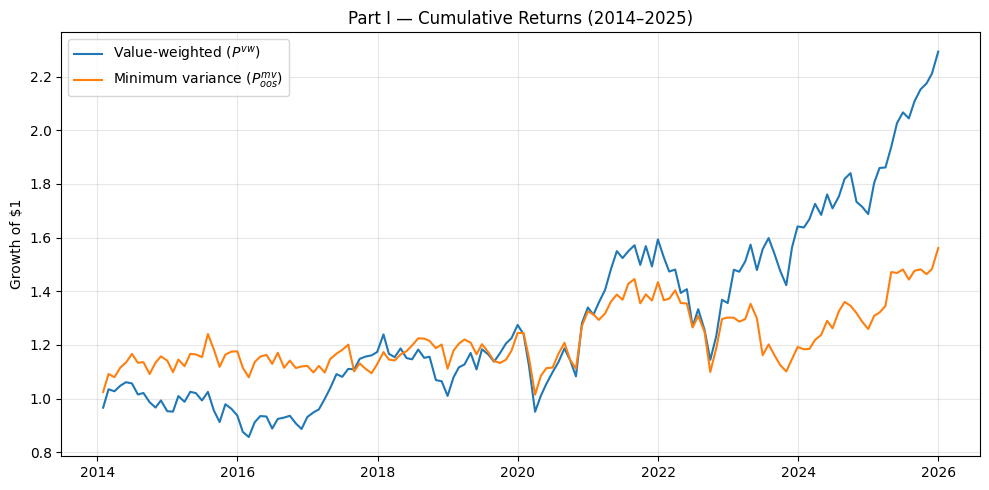

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
cum = (1.0 + monthly_returns[["R_vw", "R_mv"]]).cumprod()
ax.plot(cum.index, cum["R_vw"], label="Value-weighted ($P^{vw}$)", color="tab:blue")
ax.plot(cum.index, cum["R_mv"], label="Minimum variance ($P^{mv}_{oos}$)", color="tab:orange")
ax.set_title("Part I — Cumulative Returns (2014–2025)")
ax.set_ylabel("Growth of $1")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_PART1 / "part1_cumulative_returns.png", dpi=150)
plt.show()


## 8. Part II — Section 3.1: Carbon metrics

We report the WACI (weighted-average carbon intensity) and CF (carbon
footprint) of $P^{(mv)}_{oos}$ and $P^{(vw)}$ year by year. The PDF defines
$$
CF(P^{(vw)})_Y = \frac{1}{\sum_i \mathrm{Cap}_{i,Y}} \sum_i E_{i,Y},
$$
which is what we compute (using *annual* market cap, as the formula
prescribes). The bar chart shows the firms driving the WACI of $P^{(vw)}$ in
the first allocation year (2013).


In [11]:
waci_cf_df = pd.DataFrame(waci_cf_rows).set_index("year").sort_index()
waci_cf_df[["WACI_vw", "CF_vw", "WACI_mv", "CF_mv"]].round(2)


,WACI_vw,CF_vw,WACI_mv,CF_mv
year,,,,
2013,136.07,214.22,61.70,27.19
2014,127.12,185.45,243.70,1583.48
2015,155.24,193.40,173.48,423.90
2016,150.24,205.34,184.94,1044.91
2017,171.57,185.36,250.66,366.54
2018,134.93,143.75,132.70,180.46
2019,139.05,153.28,76.25,35.89
2020,132.00,124.96,145.07,55.59
2021,133.83,117.50,121.78,37.95


In [12]:
top10_vw_2013.round(4)


,rank,ISIN,NAME,weight_vw_pct,carbon_intensity,contribution_waci_vw
0,1,CH0012214059,HOLCIM,0.3202,4279.0551,13.7025
1,2,GB0007188757,RIO TINTO,1.0143,754.2406,7.6502
2,3,DE0007037129,RWE,0.2712,2405.9254,6.5240
3,4,FR0000120073,L AIR LQE.SC.ANYME. POUR L ETUDE ET L EPXTN.,0.5092,1036.6770,5.2788
4,5,FI0009007132,FORTUM,0.2113,2491.2482,5.2649
5,6,IT0003128367,ENEL,0.5011,1027.1073,5.1467
6,7,DE0006047004,HEIDELBERG MATERIALS,0.1508,3082.9709,4.6493
7,8,ES0130670112,ENDESA,0.3102,1260.6917,3.9113
8,9,FR0010242511,EDF DEAD - DELIST.08/06/23,0.4463,806.7167,3.6001
9,10,GB00B1VNSX38,DRAX GROUP,0.0469,7355.9929,3.4478


## 9. Part II — Sections 3.2–3.3: $P^{(mv)}_{oos}(0.5)$ and $P^{(vw)}_{oos}(0.5)$

These two portfolios use the carbon footprint cap at 50% of the corresponding
unconstrained portfolio (MV and VW respectively). The MV(0.5) variant
minimizes variance; the VW(0.5) variant minimizes tracking error vs. the
value-weighted benchmark.


In [13]:
part2_34_table = stats_table({
    "P_mv_oos": r_mv,
    "P_mv_oos(0.5)": r_mv_cf,
    "P_vw": r_vw,
    "P_vw_oos(0.5)": r_vw_cf,
})
part2_34_table.round(4)


,P_mv_oos,P_mv_oos(0.5),P_vw,P_vw_oos(0.5)
Annualized average return,0.0467,0.0484,0.0818,0.0785
Annualized volatility,0.1377,0.1356,0.1581,0.1598
Annualized cumulative return,0.0378,0.0399,0.0716,0.0678
Sharpe ratio,0.3393,0.3569,0.5177,0.4914
Minimum monthly return,-0.1200,-0.1142,-0.1530,-0.1602
Maximum monthly return,0.1424,0.1351,0.1828,0.1878


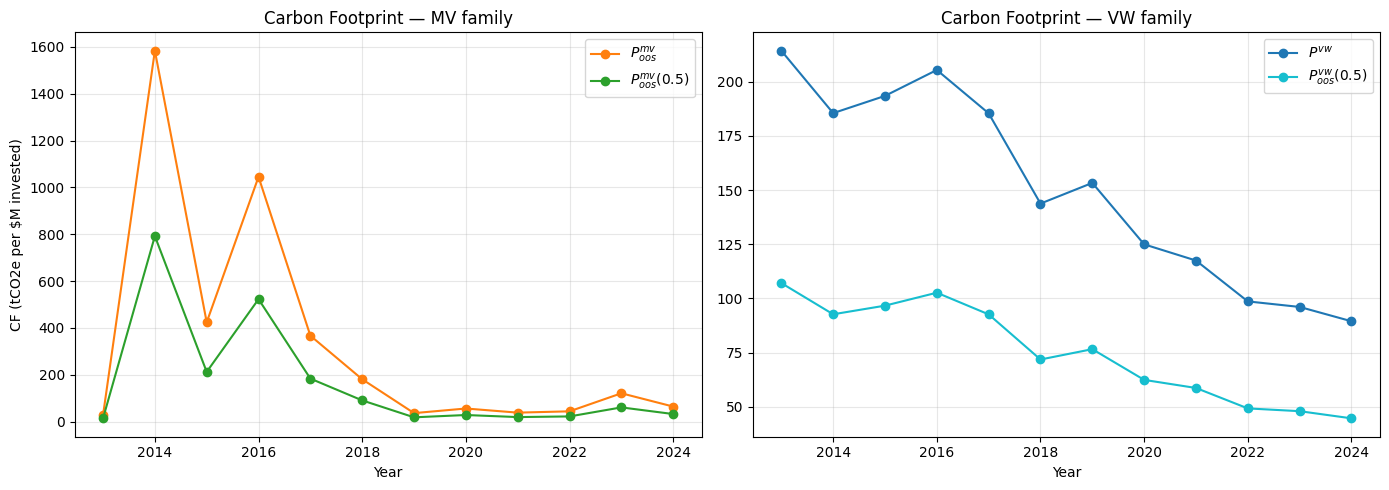

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(waci_cf_df.index, waci_cf_df["CF_mv"], label="$P^{mv}_{oos}$", color="tab:orange", marker="o")
axes[0].plot(waci_cf_df.index, waci_cf_df["CF_mv_cf50"], label="$P^{mv}_{oos}(0.5)$", color="tab:green", marker="o")
axes[0].set_title("Carbon Footprint — MV family")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("CF (tCO2e per $M invested)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(waci_cf_df.index, waci_cf_df["CF_vw"], label="$P^{vw}$", color="tab:blue", marker="o")
axes[1].plot(waci_cf_df.index, waci_cf_df["CF_vw_cf50"], label="$P^{vw}_{oos}(0.5)$", color="tab:cyan", marker="o")
axes[1].set_title("Carbon Footprint — VW family")
axes[1].set_xlabel("Year")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_PART2 / "part2_carbon_footprint_split.png", dpi=150)
plt.show()


## 10. Part II — Section 4: Net Zero ($P^{(vw)}_{oos}(NZ)$) and final comparison

The Net Zero portfolio applies a 10% cumulative reduction per year to the
2013 baseline of the VW carbon footprint. By 2024 it requires a $\sim$72%
reduction below the 2013 level. The TE-minimization keeps the realized return
close to the VW benchmark; the carbon trajectory follows the prescribed
path.


In [15]:
part2_42_table = stats_table({
    "P_vw": r_vw,
    "P_vw_oos(0.5)": r_vw_cf,
    "P_vw_oos(NZ)": r_vw_nz,
})
part2_42_table.round(4)


,P_vw,P_vw_oos(0.5),P_vw_oos(NZ)
Annualized average return,0.0818,0.0785,0.0792
Annualized volatility,0.1581,0.1598,0.1601
Annualized cumulative return,0.0716,0.0678,0.0684
Sharpe ratio,0.5177,0.4914,0.4945
Minimum monthly return,-0.1530,-0.1602,-0.1588
Maximum monthly return,0.1828,0.1878,0.1882


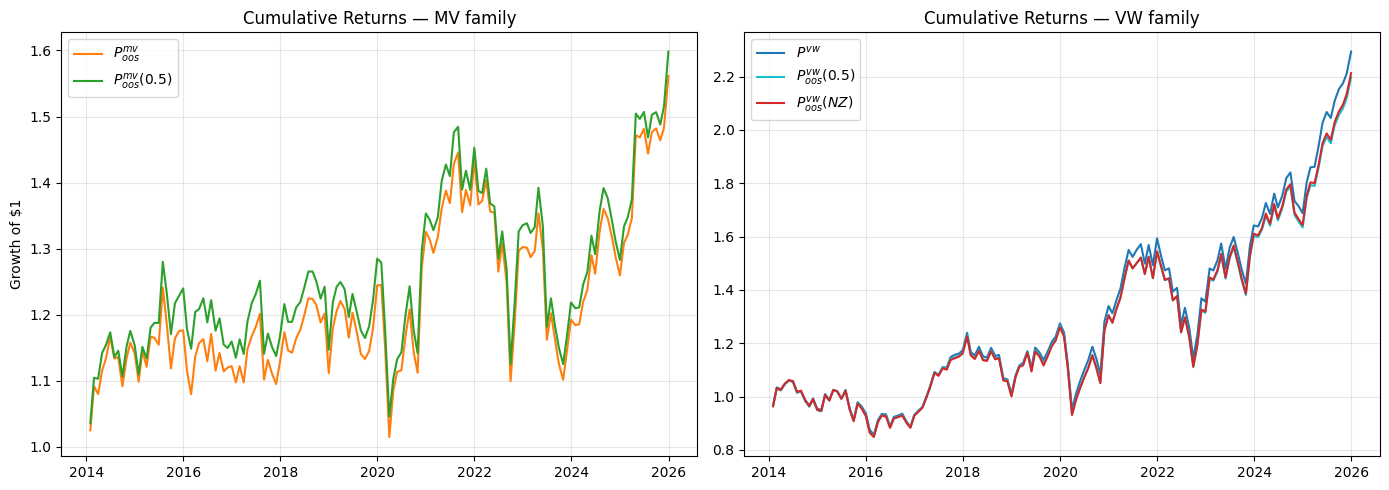

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cum = (1.0 + monthly_returns).cumprod()
axes[0].plot(cum.index, cum["R_mv"], label="$P^{mv}_{oos}$", color="tab:orange")
axes[0].plot(cum.index, cum["R_mv_cf50"], label="$P^{mv}_{oos}(0.5)$", color="tab:green")
axes[0].set_title("Cumulative Returns — MV family")
axes[0].set_ylabel("Growth of $1")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(cum.index, cum["R_vw"], label="$P^{vw}$", color="tab:blue")
axes[1].plot(cum.index, cum["R_vw_cf50"], label="$P^{vw}_{oos}(0.5)$", color="tab:cyan")
axes[1].plot(cum.index, cum["R_vw_nz"], label="$P^{vw}_{oos}(NZ)$", color="tab:red")
axes[1].set_title("Cumulative Returns — VW family")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_PART2 / "part2_cumulative_returns.png", dpi=150)
plt.show()


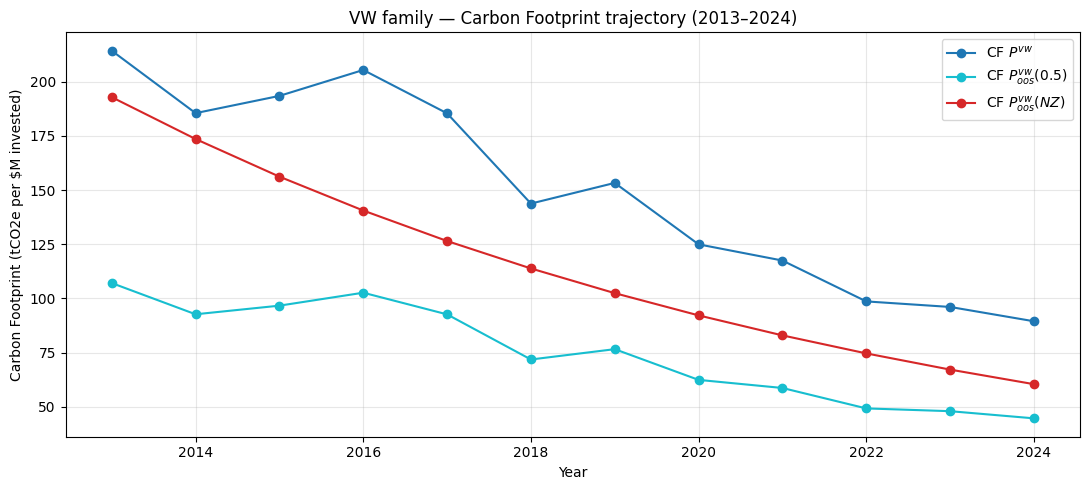

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(waci_cf_df.index, waci_cf_df["CF_vw"], label="CF $P^{vw}$", color="tab:blue", marker="o")
ax.plot(waci_cf_df.index, waci_cf_df["CF_vw_cf50"], label="CF $P^{vw}_{oos}(0.5)$", color="tab:cyan", marker="o")
ax.plot(waci_cf_df.index, waci_cf_df["CF_vw_nz"], label="CF $P^{vw}_{oos}(NZ)$", color="tab:red", marker="o")
ax.set_title("VW family — Carbon Footprint trajectory (2013–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Carbon Footprint (tCO2e per $M invested)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_PART2 / "part2_carbon_footprint_vw_family.png", dpi=150)
plt.show()


## 11. Persist all results to disk

We save the monthly returns, summary statistics, WACI/CF tables, and the
top-10 VW contributors. These exact files are referenced by the report.


In [18]:
monthly_returns.to_csv(OUTPUT_PART2 / "part2_monthly_returns_2014_2025.csv")
monthly_returns[["R_mv", "R_vw"]].to_csv(OUTPUT_PART1 / "part1_monthly_returns_2014_2025.csv")

part1_summary = pd.DataFrame([
    {"portfolio": "P_oos_mv", **annualized_stats(r_mv)},
    {"portfolio": "P_oos_vw", **annualized_stats(r_vw)},
])
part1_summary.to_csv(OUTPUT_PART1 / "part1_summary_stats.csv", index=False)

part2_summary = pd.DataFrame([
    {"portfolio": "P_oos_mv", **annualized_stats(r_mv)},
    {"portfolio": "P_oos_vw", **annualized_stats(r_vw)},
    {"portfolio": "P_oos_mv_cf50", **annualized_stats(r_mv_cf)},
    {"portfolio": "P_oos_vw_cf50", **annualized_stats(r_vw_cf)},
    {"portfolio": "P_oos_vw_nz", **annualized_stats(r_vw_nz)},
])
part2_summary.to_csv(OUTPUT_PART2 / "part2_summary_stats.csv", index=False)

waci_cf_df.to_csv(OUTPUT_PART2 / "part2_waci_cf_by_year.csv")
top10_vw_2013.to_csv(OUTPUT_PART2 / "part2_top10_waci_contributors_vw_2013.csv", index=False)

print("All deliverable files written under outputs_part1/ and outputs_part2/.")


All deliverable files written under outputs_part1/ and outputs_part2/.


## 12. End

This notebook is a single self-contained reproducer. With the raw
Datastream files in `./data_raw/`, "Run All" reproduces every table and
figure cited in the report.
